In [30]:

import sys
if 'google.colab' in sys.modules:
    !pip install utdquake

lib = None
lib = "/home/emmanuel/ecastillo/dev/utdquake"
if lib is not None:
    sys.path.append(lib)

# Version (Required)

In [31]:
import utdquake
from packaging.version import Version

current_version = Version(utdquake.__version__)
required_version = Version("0.0.14")

if current_version < required_version:
    raise Exception(f"Please update utdquake to at least version {required_version}")

# UTDClient

## get custom stations

In [32]:
from utdquake.clients.fdsn.client import Client

provider = "texnet"
out = "./custom_events"

client =  Client(provider)
sta = client.get_custom_stations(output_folder=out,network="TX,4O",station="*")
print(sta.head(10))

      sta_id network station   latitude   longitude  elevation  \
0    4O.LWM1      4O    LWM1  31.231200 -103.630000      826.8   
1    4O.LWM2      4O    LWM2  31.269900 -103.584700      810.6   
2    4O.PR01      4O    PR01  31.236500 -103.270332      826.0   
3    4O.DB04      4O    DB04  31.066400 -103.105400      868.0   
4    4O.DB03      4O    DB03  31.116200 -103.078000      839.0   
5    4O.DB02      4O    DB02  31.185800 -103.109600      820.0   
7    4O.WB01      4O    WB01  31.721667 -104.060278      927.0   
8   4O.MBBB1      4O   MBBB1  32.246247 -101.891070      855.0   
9    4O.CF01      4O    CF01  32.801840 -100.583180      640.0   
10   4O.CT01      4O    CT01  31.902850 -104.144532      994.0   

                 starttime             endtime  \
0  2019-07-26 18:00:00.000 2030-11-04 20:44:14   
1  2019-07-26 18:00:00.000 2030-11-04 20:44:14   
2  2020-02-27 00:00:00.000 2030-11-04 20:44:14   
3  2021-02-22 01:05:58.000 2030-11-04 20:44:14   
4  2021-02-22 01:05:58.

## get custom events

In [33]:
from obspy import UTCDateTime
from utdquake.clients.fdsn.client import Client

region = [-104.84329,-103.79942,31.39610,31.91505]
provider = "USGS"
out = "./custom_events"

client =  Client(provider)
cat,picks,mag = client.get_custom_events(starttime=UTCDateTime("2024-04-18T23:00:00"),
                        endtime=UTCDateTime("2024-04-19T23:00:00"),
                        minlatitude=region[2], maxlatitude=region[3],
                        minlongitude=region[0], maxlongitude=region[1],
                        debug=True,
                        output_folder=out,
                        )


Event id 1/7: tx2024hrey
Event id 2/7: tx2024hrgy
Event id 3/7: tx2024hriz
Event id 4/7: tx2024hrlf
Event id 5/7: tx2024hrwl
Event id 6/7: tx2024hrwo
Event id 7/7: tx2024hstr


# How to read?

FIles in your ouput folder

In [34]:
import os
print(os.listdir(out))

['mags.db', 'stations.csv', 'picks.db', 'origin.csv']


picks and mags are in database format

In [35]:
import os

stations_path = os.path.join(out,"stations.csv")
events_path = os.path.join(out,"origin.csv")
picks_path = os.path.join(out,"picks.db")
mags_path = os.path.join(out,"mags.db")

read_stations

In [36]:
import pandas as pd
from utdquake.core.event.stations import Stations
stations_data = pd.read_csv(stations_path)
stations = Stations(stations_data,xy_epsg="EPSG:3116",author="Texas")
print(stations)

Stations | 241 stations


read catalog

In [37]:
from utdquake.core.event.catalog import read_catalog
catalog = read_catalog(events_path=events_path,
                       xy_epsg="EPSG:3116",
                       stations_path=stations_path)
catalog.sample(5)
print(catalog)


Catalog | 5 events, stations: True


get_picks

In [38]:
import random

picks = catalog.get_picks(picks_path=picks_path,author="manual")
picks.dropna(subset=["utdq_distance"]) #drop picks without distance

#FIRST ADD ARTIFICIAL PICKS, THEN REMOVE SOME RANDOMLY
picks.add_artificial_picks(events=catalog.events,
                           distances=[random.uniform(0, 60) for _ in range(4)], #4 stations
                           phase_type=["P","S"])
picks.remove_phases_randomly(keep_ratio_p=0.8,keep_ratio_s=0.5)
print(picks)

Picks | 436 picks, (5 events-46 stations)


/home/emmanuel/ecastillo/dev/utdquake/utdquake/core/event/events.py:158: UserWarning: Some stations do not have coordinates. Activate debug mode in Events.get_picks to display them.
  warnings.warn("Some stations do not have coordinates. Activate debug mode in Events.get_picks to display them.")


# Window

In [39]:
from utdquake.core.dataset.window import EQWindow
eqw = EQWindow()
eqw.add_picks(picks)
eqw.add_noise(stations)
window = eqw.get_window()

In [40]:
window.head(10)

,ev_id,network,station,location,channel,phase_hint,time,time_lower_error,time_upper_error,author,...,time_weight,used,utdq_real,utdq_distance,utdq_azimuth,utdq_bazimuth,utdq_time,utdq_r2,utdq_r2_length,utdq_wtime
0,tx2024hrey,TX,PB13,01,HHN,P,2024-04-19 00:33:30.972988000,0.3,0.3,Anestis,...,0.805510,1.0,True,8.187932,26.293424,206.313396,1.889714,1.0,30.0,108.999162
1,tx2024hrey,4O,WB04,00,HHZ,P,2024-04-19 00:33:31.222610000,0.3,0.3,Anestis,...,1.040132,1.0,True,7.868136,306.822495,126.787834,2.139336,1.0,30.0,109.248784
0,tx2024hrey,UTDQ,UTDQ_2,NaN,NaN,P,2024-04-19 00:33:31.627937234,NaN,NaN,utdquake,...,NaN,NaN,True,8.603118,342.611891,162.611891,2.544663,1.0,30.0,109.654111
0,tx2024hrey,UTDQ,UTDQ_3,NaN,NaN,P,2024-04-19 00:33:31.745627751,NaN,NaN,utdquake,...,NaN,NaN,True,9.361952,34.405654,214.405654,2.662353,1.0,30.0,109.771801
0,tx2024hrey,UTDQ,UTDQ_0,NaN,NaN,P,2024-04-19 00:33:31.850228263,NaN,NaN,utdquake,...,NaN,NaN,True,10.036386,250.932861,70.932861,2.766954,1.0,30.0,109.876402
2,tx2024hrey,TX,PECS,00,HH2,P,2024-04-19 00:33:32.130765000,0.2,0.2,Anestis,...,1.212390,1.0,True,13.133759,172.914220,352.923100,3.047491,1.0,30.0,110.156939
3,tx2024hrey,4O,WB03,00,HHN,P,2024-04-19 00:33:32.751721000,0.2,0.2,Anestis,...,0.000000,1.0,True,15.812964,329.396199,149.351809,3.668447,1.0,30.0,110.777895
4,tx2024hrey,TX,PB33,00,HH1,P,2024-04-19 00:33:32.820194000,0.3,0.3,Anestis,...,1.014601,1.0,True,16.970122,287.900179,107.811302,3.736920,1.0,30.0,110.846368
5,tx2024hrey,TX,PB40,00,HH1,P,2024-04-19 00:33:32.888062000,0.2,0.2,Anestis,...,1.217838,1.0,True,17.721172,344.489119,164.462967,3.804788,1.0,30.0,110.914236
6,tx2024hrey,TX,PB24,00,HHE,P,2024-04-19 00:33:33.169665000,0.2,0.2,Anestis,...,1.220233,1.0,True,19.360468,319.040456,138.970460,4.086391,1.0,30.0,111.195839


In [41]:
window.info()

<class 'pandas.core.frame.DataFrame'>
Index: 291 entries, 0 to 93
Data columns (total 30 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   ev_id              197 non-null    object        
 1   network            291 non-null    object        
 2   station            291 non-null    object        
 3   location           146 non-null    object        
 4   channel            157 non-null    object        
 5   phase_hint         291 non-null    object        
 6   time               197 non-null    datetime64[ns]
 7   time_lower_error   157 non-null    float64       
 8   time_upper_error   157 non-null    float64       
 9   author             197 non-null    object        
 10  filter_id          40 non-null     object        
 11  method_id          0 non-null      object        
 12  polarity           37 non-null     object        
 13  evaluation_mode    157 non-null    object        
 14  evaluation_statu

In [42]:
window[(window["author"]=="utdquake") & (window["utdq_real"]==True)].head(10)

,ev_id,network,station,location,channel,phase_hint,time,time_lower_error,time_upper_error,author,...,time_weight,used,utdq_real,utdq_distance,utdq_azimuth,utdq_bazimuth,utdq_time,utdq_r2,utdq_r2_length,utdq_wtime
0,tx2024hrey,UTDQ,UTDQ_2,NaN,NaN,P,2024-04-19 00:33:31.627937234,NaN,NaN,utdquake,...,NaN,NaN,True,8.603118,342.611891,162.611891,2.544663,1.0,30.0,109.654111
0,tx2024hrey,UTDQ,UTDQ_3,NaN,NaN,P,2024-04-19 00:33:31.745627751,NaN,NaN,utdquake,...,NaN,NaN,True,9.361952,34.405654,214.405654,2.662353,1.0,30.0,109.771801
0,tx2024hrey,UTDQ,UTDQ_0,NaN,NaN,P,2024-04-19 00:33:31.850228263,NaN,NaN,utdquake,...,NaN,NaN,True,10.036386,250.932861,70.932861,2.766954,1.0,30.0,109.876402
0,tx2024hrey,UTDQ,UTDQ_2,NaN,NaN,S,2024-04-19 00:33:33.367809756,NaN,NaN,utdquake,...,NaN,NaN,True,8.603118,29.835768,209.835768,4.284535,1.0,30.0,111.393983
0,tx2024hrey,UTDQ,UTDQ_3,NaN,NaN,S,2024-04-19 00:33:33.592787885,NaN,NaN,utdquake,...,NaN,NaN,True,9.361952,9.963883,189.963883,4.509513,1.0,30.0,111.618961
0,tx2024hrey,UTDQ,UTDQ_0,NaN,NaN,S,2024-04-19 00:33:33.792743056,NaN,NaN,utdquake,...,NaN,NaN,True,10.036386,52.125800,232.125800,4.709469,1.0,30.0,111.818917
0,tx2024hrey,UTDQ,UTDQ_1,NaN,NaN,P,2024-04-19 00:33:36.524149414,NaN,NaN,utdquake,...,NaN,NaN,True,40.172454,328.592451,148.592451,7.440875,1.0,30.0,114.550323
0,tx2024hrey,UTDQ,UTDQ_1,NaN,NaN,S,2024-04-19 00:33:42.727447950,NaN,NaN,utdquake,...,NaN,NaN,True,40.172454,117.845748,297.845748,13.644173,1.0,30.0,120.753621
0,tx2024hrgy,UTDQ,UTDQ_2,NaN,NaN,P,2024-04-19 01:33:54.319586678,NaN,NaN,utdquake,...,NaN,NaN,True,8.603118,132.860030,312.860030,2.475373,1.0,30.0,150.053590
0,tx2024hrgy,UTDQ,UTDQ_3,NaN,NaN,P,2024-04-19 01:33:54.436811430,NaN,NaN,utdquake,...,NaN,NaN,True,9.361952,176.063151,356.063151,2.592598,1.0,30.0,150.170815


# Important

keep in mind columns like: 
- ev_id (to know the event info)
- station
- author
- utdq columns 

NOtes:

utdq_r2 refers to Rsquare for the line used to create artificial picks. 1 if it's real 

utdq_r2_length  refers to the number of picks used to obtained the best fit.



# Plots

some plots for illustration

/tmp/ipykernel_56487/3768091752.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  false["utdq_distance"] = [random.uniform(0, 60) for _ in range(len(false))]


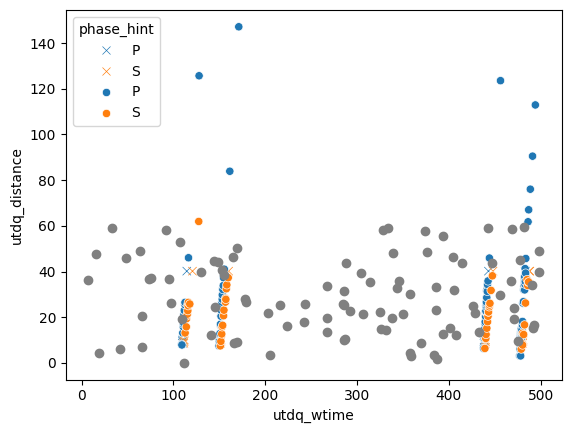

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns
import random

false = window[window["utdq_real"]==False]
false["utdq_distance"] = [random.uniform(0, 60) for _ in range(len(false))]

real_artificial = window[(window["utdq_real"]==True) & (window["author"]=="utdquake")]
real_manual = window[(window["utdq_real"]==True) & (window["author"]!="utdquake")]
# (window["author"]=="utdquake") & 

fig,ax = plt.subplots()
ax.plot(false["utdq_wtime"], false["utdq_distance"], 'o',color="gray")
sns.scatterplot(data=real_artificial, x='utdq_wtime', y='utdq_distance', 
                hue='phase_hint', palette='tab10',
                marker="x",
                ax=ax)
sns.scatterplot(data=real_manual, x='utdq_wtime', y='utdq_distance', 
                hue='phase_hint', palette='tab10',ax=ax)
# ax.plot(window["utdq_wtime"], window["utdq_distance"], 'o',color="darkorange")
# plt.plot(window["utdq_wtime"], window["station"], 'o')
plt.show()

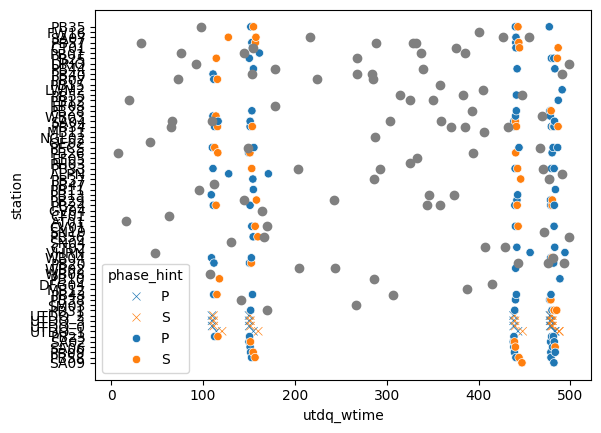

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns


false = window[window["utdq_real"]==False]
real_artificial = window[(window["utdq_real"]==True) & (window["author"]=="utdquake")]
real_manual = window[(window["utdq_real"]==True) & (window["author"]!="utdquake")]
# (window["author"]=="utdquake") & 

fig,ax = plt.subplots()
ax.plot(false["utdq_wtime"], false["station"], 'o',color="gray")
sns.scatterplot(data=real_artificial, x='utdq_wtime', y='station', 
                hue='phase_hint', palette='tab10',
                marker="x",
                ax=ax)
sns.scatterplot(data=real_manual, x='utdq_wtime', y='station', 
                hue='phase_hint', palette='tab10',ax=ax)
# ax.plot(window["utdq_wtime"], window["utdq_distance"], 'o',color="darkorange")
# plt.plot(window["utdq_wtime"], window["station"], 'o')
plt.show()

# save your windows in hsf format

In [45]:
window.to_hdf("window.h5",key="window_1",mode="w")

/tmp/ipykernel_56487/1952062211.py:1: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed,key->block3_values] [items->Index(['ev_id', 'network', 'station', 'location', 'channel', 'phase_hint',
       'author', 'filter_id', 'method_id', 'polarity', 'evaluation_mode',
       'evaluation_status'],
      dtype='object')]

  window.to_hdf("window.h5",key="window_1",mode="w")


In [48]:
window_1 = pd.read_hdf("window.h5",key="window_1")
window_1

,ev_id,network,station,location,channel,phase_hint,time,time_lower_error,time_upper_error,author,...,time_weight,used,utdq_real,utdq_distance,utdq_azimuth,utdq_bazimuth,utdq_time,utdq_r2,utdq_r2_length,utdq_wtime
0,tx2024hrey,TX,PB13,01,HHN,P,2024-04-19 00:33:30.972988000,0.3,0.3,Anestis,...,0.805510,1.0,True,8.187932,26.293424,206.313396,1.889714,1.0,30.0,108.999162
1,tx2024hrey,4O,WB04,00,HHZ,P,2024-04-19 00:33:31.222610000,0.3,0.3,Anestis,...,1.040132,1.0,True,7.868136,306.822495,126.787834,2.139336,1.0,30.0,109.248784
0,tx2024hrey,UTDQ,UTDQ_2,NaN,NaN,P,2024-04-19 00:33:31.627937234,NaN,NaN,utdquake,...,NaN,NaN,True,8.603118,342.611891,162.611891,2.544663,1.0,30.0,109.654111
0,tx2024hrey,UTDQ,UTDQ_3,NaN,NaN,P,2024-04-19 00:33:31.745627751,NaN,NaN,utdquake,...,NaN,NaN,True,9.361952,34.405654,214.405654,2.662353,1.0,30.0,109.771801
0,tx2024hrey,UTDQ,UTDQ_0,NaN,NaN,P,2024-04-19 00:33:31.850228263,NaN,NaN,utdquake,...,NaN,NaN,True,10.036386,250.932861,70.932861,2.766954,1.0,30.0,109.876402
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89,NaN,TX,PB01,NaN,NaN,P,NaT,NaN,NaN,NaN,...,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,75.665634
90,NaN,TX,PB31,NaN,NaN,S,NaT,NaN,NaN,NaN,...,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,169.746192
91,NaN,TX,PB33,NaN,NaN,S,NaT,NaN,NaN,NaN,...,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,203.084068
92,NaN,4O,SA07,NaN,NaN,S,NaT,NaN,NaN,NaN,...,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,455.335516


In [50]:
window_1[window_1["utdq_r2"]!=1 ].head(10)

,ev_id,network,station,location,channel,phase_hint,time,time_lower_error,time_upper_error,author,...,time_weight,used,utdq_real,utdq_distance,utdq_azimuth,utdq_bazimuth,utdq_time,utdq_r2,utdq_r2_length,utdq_wtime
0,tx2024hstr,UTDQ,UTDQ_3,NaN,NaN,S,2024-04-19 21:08:34.723789388,NaN,NaN,utdquake,...,NaN,NaN,True,9.361952,70.953674,250.953674,4.254681,0.99844,30.0,439.777364
0,NaN,TX,PB35,NaN,NaN,P,NaT,NaN,NaN,NaN,...,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,97.273603
1,NaN,TX,FW16,NaN,NaN,S,NaT,NaN,NaN,NaN,...,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,400.828388
2,NaN,4O,SA07,NaN,NaN,P,NaT,NaN,NaN,NaN,...,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,216.353076
3,NaN,TX,PB57,NaN,NaN,P,NaT,NaN,NaN,NaN,...,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,32.990328
4,NaN,4O,CT01,NaN,NaN,S,NaT,NaN,NaN,NaN,...,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,375.890867
5,NaN,TX,PB01,NaN,NaN,P,NaT,NaN,NaN,NaN,...,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,385.659139
6,NaN,TX,PB25,NaN,NaN,S,NaT,NaN,NaN,NaN,...,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,267.751093
7,NaN,TX,DRIO,NaN,NaN,P,NaT,NaN,NaN,NaN,...,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,498.306242
8,NaN,TX,PB01,NaN,NaN,S,NaT,NaN,NaN,NaN,...,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,337.732946
